# Audio Capture + Voice Activity Detection (VAD)

This notebook adds WebRTC VAD to detect speech vs silence in recorded audio.

## What this tests
- Converting float32 audio to int16 (required by WebRTC VAD)
- Frame-by-frame speech detection
- Extracting only speech segments
- Visualizing speech detection results

## Why VAD matters
- Removes silence before/after speech
- Reduces STT processing time
- Filters out background noise

## Dependencies
```bash
pip install sounddevice webrtcvad-wheels scipy matplotlib
```

In [ ]:
# Configuration for WebRTC VAD
# Note: VAD only accepts specific frame durations (20ms, 30ms, or 60ms)

SAMPLE_RATE = 16000      # 16kHz is required for WebRTC VAD
FRAME_DURATION = 20      # 20ms frames (must be 20, 30, or 60)
FRAME_SIZE = int(SAMPLE_RATE * FRAME_DURATION / 1000)  # 320 samples per frame

# VAD mode: 0 (least aggressive) to 3 (most aggressive)
# Mode 2 is a good balance - filters noise but catches all speech
VAD_MODE = 2

vad = webrtcvad.Vad(VAD_MODE)
print(f"VAD initialized with mode {VAD_MODE}")
print(f"Frame size: {FRAME_SIZE} samples ({FRAME_DURATION}ms)")

In [5]:
# =========================
# IMPORT LIBRARIES
# =========================

import sounddevice as sd
import numpy as np
import webrtcvad
import matplotlib.pyplot as plt

from scipy.io.wavfile import write
from scipy.io import wavfile
from IPython.display import Audio


In [6]:
def record_audio(seconds=5, filename="input.wav", sample_rate=16000):

    print("Recording...")

    audio = sd.rec(
        int(seconds * sample_rate),
        samplerate=sample_rate,
        channels=1,
        dtype="float32"
    )

    sd.wait()

    write(filename, sample_rate, audio)

    print("Saved:", filename)

    return filename

In [7]:
# =========================
# CONVERT FLOAT32 → INT16
# =========================

def float32_to_int16(audio):

    audio = audio.flatten()

    audio_int16 = np.int16(audio * 32767)

    return audio_int16


In [8]:
# =========================
# FRAME GENERATOR
# =========================

def frame_generator(audio, frame_size):

    for i in range(0, len(audio), frame_size):
        yield audio[i:i+frame_size]


In [9]:
# =========================
# EXTRACT SPEECH USING VAD
# =========================

def extract_speech(audio, rate):

    vad = webrtcvad.Vad(2)

    frame_size = int(rate * 0.02)  # 20 ms frames

    frames = frame_generator(audio, frame_size)

    speech_audio = []

    speech_flags = []

    for frame in frames:

        if len(frame) < frame_size:
            continue

        is_speech = vad.is_speech(frame.tobytes(), rate)

        speech_flags.append(is_speech)

        if is_speech:
            speech_audio.extend(frame)

    return np.array(speech_audio, dtype=np.int16), speech_flags


In [10]:
# =========================
# RUN PIPELINE
# =========================

In [11]:
# 1 record audio
audio_file = record_audio(5)

Recording...
Saved: input.wav


In [12]:
# 2 load audio
rate, data = wavfile.read(audio_file)

In [13]:
print("Rate:", rate)
print("Dtype:", data.dtype)
print("Shape:", data.shape)


Rate: 16000
Dtype: float32
Shape: (80000,)


In [14]:
# 3 convert float → int16
audio_int16 = float32_to_int16(data)

print("Converted dtype:", audio_int16.dtype)

Converted dtype: int16


In [15]:
# 4 run VAD
speech_audio, speech_flags = extract_speech(audio_int16, rate)


In [16]:
# 5 save speech-only audio
write("speech_only.wav", rate, speech_audio)

print("Saved speech_only.wav")

Saved speech_only.wav


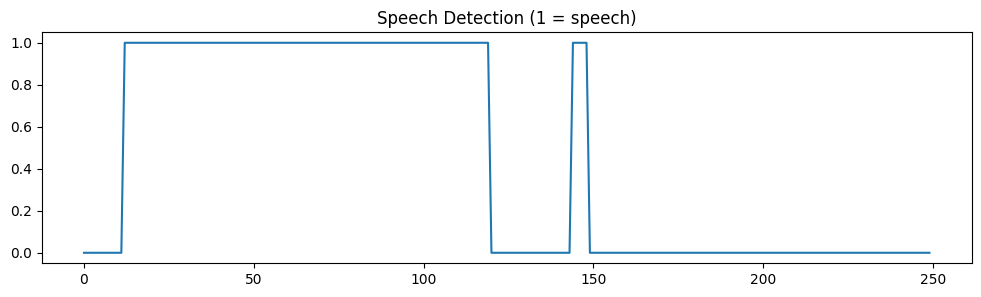

In [17]:
# =========================
# VISUALIZE SPEECH DETECTION
# =========================

plt.figure(figsize=(12,3))
plt.plot(speech_flags)
plt.title("Speech Detection (1 = speech)")
plt.show()


In [18]:
# =========================
# PLAY RESULTS
# =========================

print("Original audio:")
display(Audio(audio_file))

print("Speech only:")
display(Audio("speech_only.wav"))

Original audio:


Speech only:
